In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('data/olist.db')
pd.read_sql("SELECT * FROM orders LIMIT 5", conn)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [2]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

                   name
0                orders
1           order_items
2             customers
3               sellers
4              products
5        order_payments
6         order_reviews
7           geolocation
8  category_translation


In [3]:
query = """
SELECT 
    order_id,
    order_purchase_timestamp,
    order_delivered_customer_date,
    order_estimated_delivery_date
FROM orders
WHERE order_status = 'delivered'
LIMIT 10
"""
pd.read_sql(query, conn)

,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26 00:00:00
5,a4591c265e18cb1dcee52889e2d8acc3,2017-07-09 21:57:05,2017-07-26 10:57:55,2017-08-01 00:00:00
6,6514b8ad8028c9f2cc2374ded245783f,2017-05-16 13:10:30,2017-05-26 12:55:51,2017-06-07 00:00:00
7,76c6e866289321a7c93b82b54852dc33,2017-01-23 18:29:09,2017-02-02 14:08:10,2017-03-06 00:00:00
8,e69bfb5eb88e0ed6a785585b27e16dbf,2017-07-29 11:55:02,2017-08-16 17:14:30,2017-08-23 00:00:00
9,e6ce16cb79ec1d90b1da9085a6118aeb,2017-05-16 19:41:10,2017-05-29 11:18:31,2017-06-07 00:00:00


In [4]:
query = """
SELECT 
    order_id,
    julianday(order_delivered_customer_date) - julianday(order_estimated_delivery_date) AS delay_days
FROM orders
WHERE order_status = 'delivered'
  AND order_delivered_customer_date IS NOT NULL
LIMIT 10
"""
pd.read_sql(query, conn)


,order_id,delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,-7.107488
1,53cdb2fc8bc7dce0b6741e2150273451,-5.355729
2,47770eb9100c2d0c44946d9cf07ec65d,-17.245498
3,949d5b44dbf5de918fe9c16f97b45f8a,-12.980069
4,ad21c59c0840e6cb83a9ceb5573f8159,-9.238171
5,a4591c265e18cb1dcee52889e2d8acc3,-5.543113
6,6514b8ad8028c9f2cc2374ded245783f,-11.461215
7,76c6e866289321a7c93b82b54852dc33,-31.410995
8,e69bfb5eb88e0ed6a785585b27e16dbf,-6.281597
9,e6ce16cb79ec1d90b1da9085a6118aeb,-8.528808


In [5]:
query = """
SELECT 
    CASE 
        WHEN julianday(order_delivered_customer_date) - julianday(order_estimated_delivery_date) > 0 
        THEN 'Late' 
        ELSE 'On Time' 
    END AS delivery_status,
    COUNT(*) AS total_orders
FROM orders
WHERE order_status = 'delivered'
  AND order_delivered_customer_date IS NOT NULL
GROUP BY delivery_status
"""
pd.read_sql(query, conn)

,delivery_status,total_orders
0,Late,7826
1,On Time,88644


In [6]:
query = """
SELECT 
    CASE 
        WHEN julianday(o.order_delivered_customer_date) - julianday(o.order_estimated_delivery_date) > 0 
        THEN 'Late' 
        ELSE 'On Time' 
    END AS delivery_status,
    ROUND(AVG(r.review_score), 2) AS avg_review_score,
    COUNT(*) AS total_orders
FROM orders o
JOIN order_reviews r ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
GROUP BY delivery_status
"""
pd.read_sql(query, conn)

,delivery_status,avg_review_score,total_orders
0,Late,2.57,7700
1,On Time,4.29,88653


In [7]:
query = """
SELECT 
    oi.seller_id,
    COUNT(*) AS total_orders,
    SUM(CASE WHEN julianday(o.order_delivered_customer_date) - julianday(o.order_estimated_delivery_date) > 0 THEN 1 ELSE 0 END) AS late_orders,
    ROUND(100.0 * SUM(CASE WHEN julianday(o.order_delivered_customer_date) - julianday(o.order_estimated_delivery_date) > 0 THEN 1 ELSE 0 END) / COUNT(*), 1) AS late_pct
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
GROUP BY oi.seller_id
HAVING total_orders >= 20
ORDER BY late_pct DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,seller_id,total_orders,late_orders,late_pct
0,2709af9587499e95e803a6498a5a56e9,46,23,50.0
1,f76a3b1349b6df1ee875d1f3fa4340f0,24,9,37.5
2,821fb029fc6e495ca4f08a35d51e53a5,25,9,36.0
3,ede0c03645598cdfc63ca8237acbe73d,47,16,34.0
4,54965bbe3e4f07ae045b90b0b8541f52,81,26,32.1
5,ad781527c93d00d89a11eecd9dcad7c1,38,12,31.6
6,835f0f7810c76831d6c7d24c7a646d4d,48,15,31.3
7,7f152321c60a266edc53af1925ef96c1,20,6,30.0
8,2a1348e9addc1af5aaa619b1a3679d6b,51,15,29.4
9,4e5725ba188db8252977a4f0227bd462,24,7,29.2


In [8]:
query = """
SELECT 
    customer_unique_id,
    COUNT(DISTINCT o.order_id) AS total_orders
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
GROUP BY customer_unique_id
ORDER BY total_orders DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,customer_unique_id,total_orders
0,8d50f5eadf50201ccdcedfb9e2ac8455,15
1,3e43e6105506432c953e165fb2acf44c,9
2,ca77025e7201e3b30c44b472ff346268,7
3,6469f99c1f9dfae7733b25662e7f1782,7
4,1b6c7548a2a1f9037c1fd3ddfed95f33,7
5,f0e310a6839dce9de1638e0fe5ab282a,6
6,dc813062e0fc23409cd255f7f53c7074,6
7,63cfc61cee11cbe306bff5857d00bfe4,6
8,47c1a3033b8b77b3ab6e109eb4d5fdf3,6
9,12f5d6e1cbf93dafd9dcc19095df0b3d,6


In [9]:
query = """
SELECT 
    CASE WHEN order_count = 1 THEN 'One-time customer' ELSE 'Repeat customer' END AS customer_type,
    COUNT(*) AS num_customers
FROM (
    SELECT customer_unique_id, COUNT(DISTINCT o.order_id) AS order_count
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY customer_unique_id
)
GROUP BY customer_type
"""
pd.read_sql(query, conn)

,customer_type,num_customers
0,One-time customer,90557
1,Repeat customer,2801


In [10]:
query = """
SELECT 
    p.product_category_name,
    COUNT(*) AS total_orders,
    ROUND(AVG(julianday(o.order_delivered_customer_date) - julianday(o.order_estimated_delivery_date)), 1) AS avg_delay_days
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
JOIN products p ON oi.product_id = p.product_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
GROUP BY p.product_category_name
HAVING total_orders >= 50
ORDER BY avg_delay_days DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,product_category_name,total_orders,avg_delay_days
0,casa_conforto,429,-9.1
1,alimentos,499,-9.2
2,audio,362,-9.5
3,fashion_underwear_e_moda_praia,127,-10.2
4,livros_importados,57,-10.4
5,eletronicos,2729,-10.4
6,construcao_ferramentas_iluminacao,301,-10.5
7,livros_tecnicos,263,-10.6
8,cine_foto,70,-10.6
9,telefonia,4430,-10.7


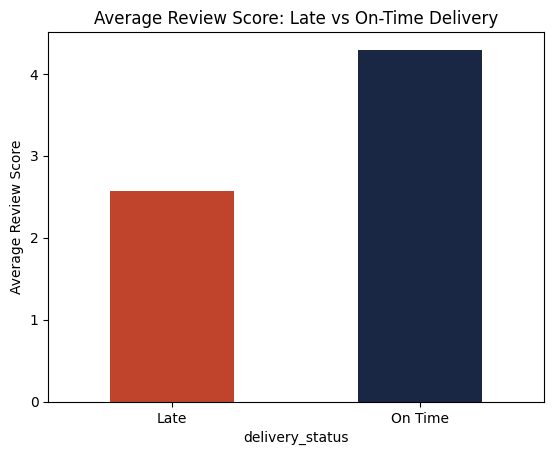

In [11]:
import matplotlib.pyplot as plt

query = """
SELECT 
    CASE 
        WHEN julianday(o.order_delivered_customer_date) - julianday(o.order_estimated_delivery_date) > 0 
        THEN 'Late' 
        ELSE 'On Time' 
    END AS delivery_status,
    r.review_score
FROM orders o
JOIN order_reviews r ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
"""
df = pd.read_sql(query, conn)

df.groupby('delivery_status')['review_score'].mean().plot(kind='bar', color=['#c0442c','#1a2744'])
plt.title('Average Review Score: Late vs On-Time Delivery')
plt.ylabel('Average Review Score')
plt.xticks(rotation=0)
plt.show()

In [12]:
plt.savefig('review_score_chart.png', bbox_inches='tight')

<Figure size 640x480 with 0 Axes>